In [4]:
%pip install geopandas matplotlib networkx

  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.9 MB 2.0 MB/s eta 0:00:12
   ---------------------------------------- 0.2/22.9 MB 2.2 MB/s eta 0:00:11
    --------------------------------------- 0.5/22.9 MB 3.7 MB/s eta 0:00:07
   - -------------------------------------- 1.0/22.9 MB 5.7 MB/s eta 0:00:04
   --- ------------------------------------ 2.0/22.9 MB 9.3 MB/s eta 0:00:03
   ------- -------------------------------- 4.3/22.9 MB 16.2 MB/s eta 0:00:02
   ----------- ---------------------------- 6.3/22.9 MB 20.2 MB/s eta 0:00:01
   ----------------- ---------------------- 9.9/22.9 MB 27.6 MB/s eta 0:00:01
   ---------------------- ----------------- 13.1/22.9 MB 65.6 MB/s eta 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
%pip install geopandas matplotlib networkx adjustText

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import json
import warnings
warnings.filterwarnings('ignore')

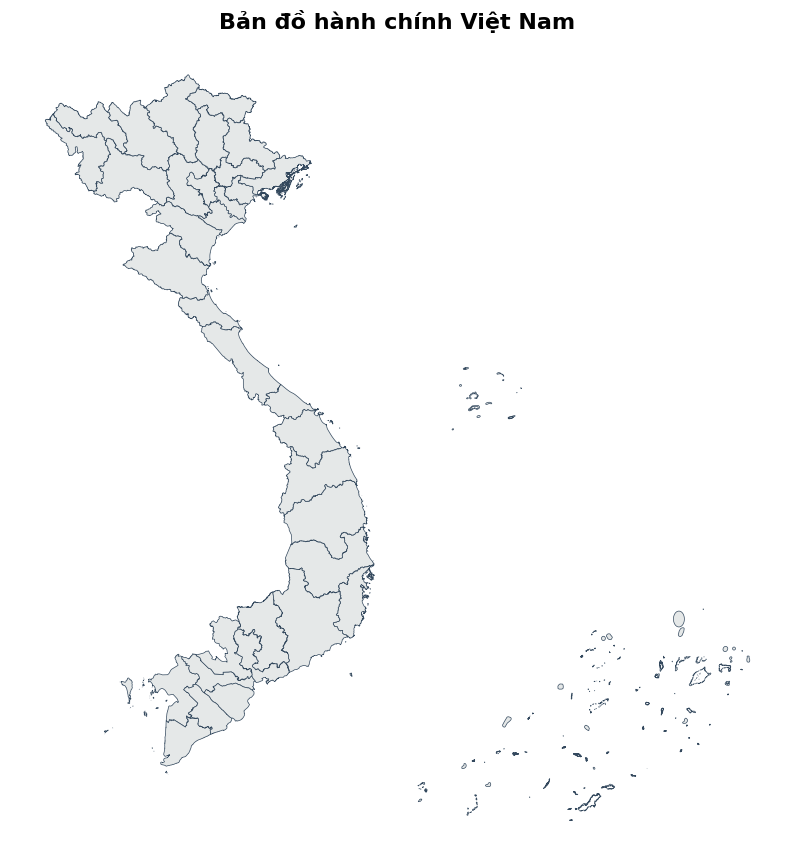

In [7]:
gdf = gpd.read_file("../data/raw/vietnam_provinces.geojson")

# Chuẩn hóa tên
gdf['Clean_Name'] = gdf['TinhThanh'].str.replace('Thành phố ', '', regex=False).str.replace('Tỉnh ', '', regex=False).str.strip()

# Trực quan hóa
fig, ax = plt.subplots(1, 1, figsize=(10, 15))
gdf.plot(ax=ax, color='#E5E8E8', edgecolor='#34495E', linewidth=0.5)

plt.title("Bản đồ hành chính Việt Nam", fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

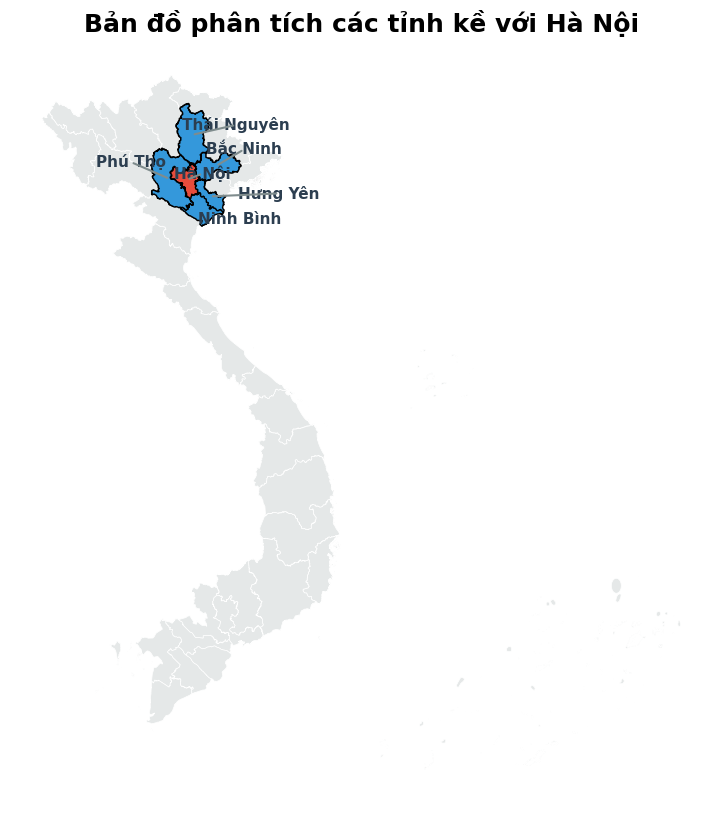

In [13]:
from adjustText import adjust_text

# Load Graph đã được xử lý
with open("../data/processed/adjacency_graph.json", "r", encoding="utf-8") as f:
    graph = json.load(f)

target_province = "Hà Nội" 
neighbors = graph.get(target_province, [])

# Trực quan hóa lên bản đồ (Zoom cận cảnh)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Vẽ nền xám
gdf.plot(ax=ax, color='#E5E8E8', edgecolor='white', linewidth=0.5)

# Tô màu Tỉnh mục tiêu (Đỏ)
gdf[gdf['Clean_Name'] == target_province].plot(ax=ax, color='#E74C3C', edgecolor='black')

# Tô màu Các tỉnh hàng xóm (Xanh dương)
gdf[gdf['Clean_Name'].isin(neighbors)].plot(ax=ax, color='#3498DB', edgecolor='black')

# --- THUẬT TOÁN ĐẶT TÊN CHỐNG ĐÈ CHỮ ---
texts = []
for idx, row in gdf[gdf['Clean_Name'].isin(neighbors + [target_province])].iterrows():
    # Lấy tọa độ tâm
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    # Tạo đối tượng Text nhưng chưa hiển thị ngay, đưa vào mảng
    t = ax.text(x, y, row['Clean_Name'], fontsize=11, fontweight='bold', color='#2C3E50', ha='center')
    texts.append(t)

# adjust_text sẽ tự động tính toán đẩy các chữ ra xa nhau và vẽ mũi tên chỉ vào tâm
adjust_text(texts, force_points=0.2, force_text=0.2,
            expand_points=(1.2, 1.2), expand_text=(1.2, 1.2),
            arrowprops=dict(arrowstyle="-", color='#7F8C8D', lw=1.5))

plt.title(f"Bản đồ phân tích các tỉnh kề với {target_province}", fontsize=18, fontweight='bold')
plt.axis('off')
plt.show()

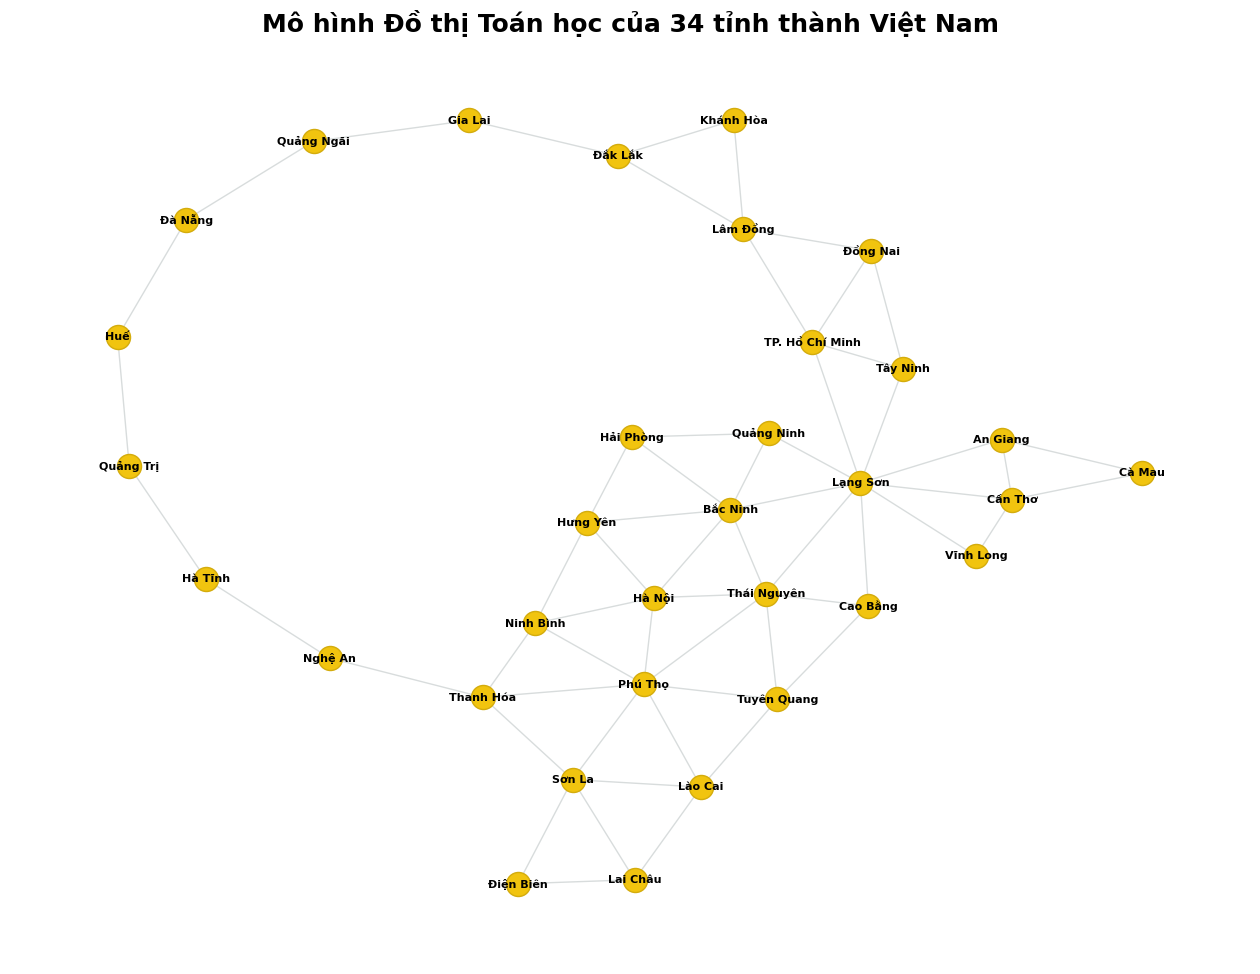

In [ ]:
# Khởi tạo đồ thị NetworkX từ file JSON
G = nx.Graph(graph)

plt.figure(figsize=(16, 12))

# Tính toán vị trí các Node
pos = nx.kamada_kawai_layout(G)

# Vẽ đồ thị
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='#F1C40F', edgecolors='#D4AC0D')
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='#7F8C8D')
nx.draw_networkx_labels(G, pos, font_size=8, font_family="sans-serif", font_weight='bold')

plt.title("Mô hình Đồ thị Toán học của 34 tỉnh thành Việt Nam", fontsize=18, fontweight='bold')
plt.axis('off')
plt.show()